In [1]:
import pandas as pd

# Load CSV file
Dataset_Train = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Train_Final.csv')
Dataset_Test = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Test_Final.csv')

# Display first 5 rows
Dataset_Train.head()
Dataset_Test.head()


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier
0,Male,No,31,Yes,Entertainment,0.0,Low,5.0,Cat_6,D,No_Low,False
1,Female,No,46,Yes,Entertainment,8.0,Low,2.0,Cat_6,D,No_Low,False
2,Male,Yes,60,Yes,Artist,0.0,Average,4.0,Cat_6,C,Yes_Average,False
3,Female,No,41,Yes,Artist,0.0,Low,1.0,Cat_6,A,No_Low,False
4,Female,Yes,52,Yes,Artist,6.0,Low,2.0,Cat_6,A,Yes_Low,False


In [2]:
import numpy as np

Dataset_Train['Segmentation_Combined'] = np.where(
    Dataset_Train['Segmentation'].isin(['A', 'B', 'C']),
    'ABC',
    Dataset_Train['Segmentation']
)

Dataset_Test['Segmentation_Combined'] = np.where(
    Dataset_Test['Segmentation'].isin(['A', 'B', 'C']),
    'ABC',
    Dataset_Test['Segmentation']
)
Dataset_Train.head()
Dataset_Test.head()

,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier,Segmentation_Combined
0,Male,No,31,Yes,Entertainment,0.0,Low,5.0,Cat_6,D,No_Low,False,D
1,Female,No,46,Yes,Entertainment,8.0,Low,2.0,Cat_6,D,No_Low,False,D
2,Male,Yes,60,Yes,Artist,0.0,Average,4.0,Cat_6,C,Yes_Average,False,ABC
3,Female,No,41,Yes,Artist,0.0,Low,1.0,Cat_6,A,No_Low,False,ABC
4,Female,Yes,52,Yes,Artist,6.0,Low,2.0,Cat_6,A,Yes_Low,False,ABC


In [3]:
#remove outlier
Dataset_Train.drop("Multivariate_Outlier", axis=1, inplace=True)
Dataset_Test.drop("Multivariate_Outlier", axis=1, inplace=True)
#remove Marital_Spending_Group
#Dataset_Train.drop("Marital_Spending_Group", axis=1, inplace=True)
#Dataset_Test.drop("Marital_Spending_Group", axis=1, inplace=True)
#remove gender
Dataset_Train = Dataset_Train.drop('Gender', axis=1)
Dataset_Test = Dataset_Test.drop('Gender', axis=1)
#remove gender
Dataset_Train = Dataset_Train.drop('Segmentation', axis=1)
Dataset_Test = Dataset_Test.drop('Segmentation', axis=1)
#remove Var_1
#Dataset_Train = Dataset_Train.drop('Var_1', axis=1)
#Dataset_Test = Dataset_Test.drop('Var_1', axis=1)
#remove Ever_Married
Dataset_Train.drop("Ever_Married", axis=1, inplace=True)
Dataset_Test.drop("Ever_Married", axis=1, inplace=True)
#remove Spending_Score
Dataset_Train.drop("Spending_Score", axis=1, inplace=True)
Dataset_Test.drop("Spending_Score", axis=1, inplace=True)

In [4]:
print("Columns in Dataset_Train:", Dataset_Train.columns.tolist())
print("Columns in Dataset_Test:", Dataset_Test.columns.tolist())

Columns in Dataset_Train: ['Age', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size', 'Var_1', 'Marital_Spending_Group', 'Segmentation_Combined']
Columns in Dataset_Test: ['Age', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size', 'Var_1', 'Marital_Spending_Group', 'Segmentation_Combined']


In [5]:
# Convert object columns to category and bool columns to numeric (0/1) in both datasets
for df in [Dataset_Train, Dataset_Test]:
    obj_cols = df.select_dtypes(include='object').columns
    bool_cols = df.select_dtypes(include='bool').columns
    df[obj_cols] = df[obj_cols].astype('category')
    df[bool_cols] = df[bool_cols].astype('int')

🔹 Class Counts:
Segmentation_Combined
ABC    6119
D      2406
Name: count, dtype: int64

🔹 Class Percentages:
Segmentation_Combined
ABC    71.78
D      28.22
Name: proportion, dtype: float64


C:\Users\Ashani Madushani\AppData\Local\Temp\ipykernel_5316\3910772525.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Segmentation_Combined', data=Dataset_Train, palette='Set2')


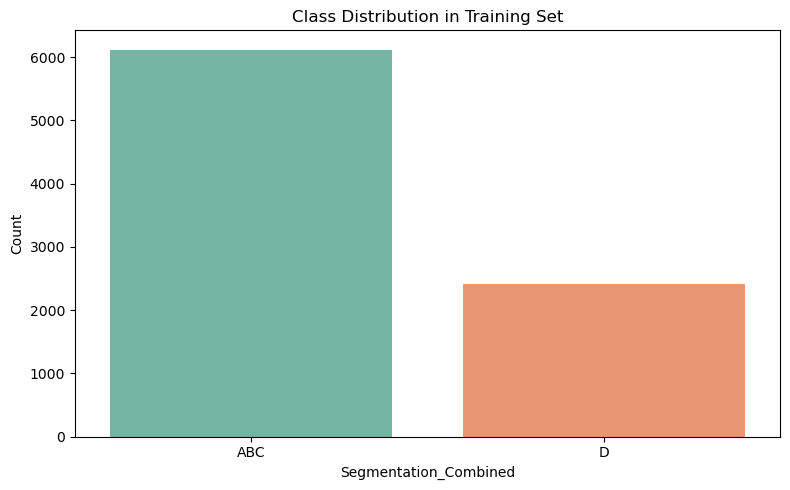

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Count the number of instances in each class
class_counts = Dataset_Train['Segmentation_Combined'].value_counts()
class_percentages = Dataset_Train['Segmentation_Combined'].value_counts(normalize=True) * 100

# Display results
print("🔹 Class Counts:")
print(class_counts)
print("\n🔹 Class Percentages:")
print(class_percentages.round(2))

# Plot class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Segmentation_Combined', data=Dataset_Train, palette='Set2')
plt.title("Class Distribution in Training Set")
plt.xlabel("Segmentation_Combined")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


✅ Train Accuracy: 0.7542521994134898
✅ Test Accuracy: 0.75

🔹 Classification Report (Train):
               precision    recall  f1-score   support

         ABC       0.87      0.77      0.82      6119
           D       0.55      0.71      0.62      2406

    accuracy                           0.75      8525
   macro avg       0.71      0.74      0.72      8525
weighted avg       0.78      0.75      0.76      8525


🔹 Classification Report (Test):
               precision    recall  f1-score   support

         ABC       0.86      0.78      0.82      1530
           D       0.55      0.68      0.61       602

    accuracy                           0.75      2132
   macro avg       0.70      0.73      0.71      2132
weighted avg       0.77      0.75      0.76      2132



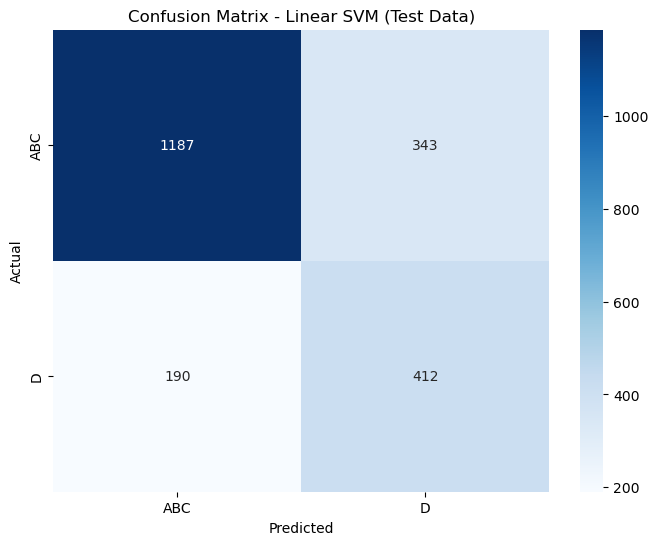

In [7]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Define features and target
X_train = Dataset_Train.drop(columns=['Segmentation_Combined'])
y_train = Dataset_Train['Segmentation_Combined']
X_test = Dataset_Test.drop(columns=['Segmentation_Combined'])
y_test = Dataset_Test['Segmentation_Combined']

# Identify column types
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Process data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Encode target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize and train Linear SVM
model = LinearSVC(
    C=1.0,  # Regularization parameter
    class_weight='balanced',  # Handle class imbalance
    max_iter=10000,  # Ensure convergence
    random_state=42,
    dual=False  # Recommended for n_samples > n_features
)
model.fit(X_train_processed, y_train_encoded)

# Predictions
y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

# Convert encoded predictions back to original labels
y_train_pred_labels = le.inverse_transform(y_train_pred)
y_test_pred_labels = le.inverse_transform(y_test_pred)

# Evaluation
print("✅ Train Accuracy:", accuracy_score(y_train, y_train_pred_labels))
print("✅ Test Accuracy:", accuracy_score(y_test, y_test_pred_labels))

print("\n🔹 Classification Report (Train):\n", classification_report(y_train, y_train_pred_labels))
print("\n🔹 Classification Report (Test):\n", classification_report(y_test, y_test_pred_labels))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Linear SVM (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [8]:
import pandas as pd

# Load CSV file
Dataset_Train = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Train_Final.csv')
Dataset_Test = pd.read_csv('C:/Users/Ashani Madushani/Desktop/Dataset_Test_Final.csv')

# Display first 5 rows
Dataset_Train.head()
Dataset_Test.head()


,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation,Marital_Spending_Group,Multivariate_Outlier
0,Female,Yes,39,No,Engineer,0.0,Low,2.0,Cat_6,A,Yes_Low,False
1,Male,No,28,Yes,Healthcare,1.0,Low,4.0,Cat_6,D,No_Low,False
2,Male,No,30,No,Healthcare,1.0,Low,4.0,Cat_2,A,No_Low,False
3,Male,Yes,62,Yes,Entertainment,1.0,Average,3.0,Cat_6,C,Yes_Average,False
4,Male,Yes,45,Yes,Artist,4.0,Average,4.0,Cat_6,B,Yes_Average,False


In [9]:
#remove outlier
Dataset_Train.drop("Multivariate_Outlier", axis=1, inplace=True)
Dataset_Test.drop("Multivariate_Outlier", axis=1, inplace=True)
#remove Marital_Spending_Group
Dataset_Train.drop("Marital_Spending_Group", axis=1, inplace=True)
Dataset_Test.drop("Marital_Spending_Group", axis=1, inplace=True)
#remove gender
Dataset_Train = Dataset_Train.drop('Gender', axis=1)
Dataset_Test = Dataset_Test.drop('Gender', axis=1)
#remove gender
#Dataset_Train = Dataset_Train.drop('Segmentation', axis=1)
#Dataset_Test = Dataset_Test.drop('Segmentation', axis=1)
#remove Var_1
#Dataset_Train = Dataset_Train.drop('Var_1', axis=1)
#Dataset_Test = Dataset_Test.drop('Var_1', axis=1)
#remove Ever_Married
#Dataset_Train.drop("Ever_Married", axis=1, inplace=True)
#Dataset_Test.drop("Ever_Married", axis=1, inplace=True)
#remove Spending_Score
#Dataset_Train.drop("Spending_Score", axis=1, inplace=True)
#Dataset_Test.drop("Spending_Score", axis=1, inplace=True)

In [10]:
# Convert object columns to category and bool columns to numeric (0/1) in both datasets
for df in [Dataset_Train, Dataset_Test]:
    obj_cols = df.select_dtypes(include='object').columns
    bool_cols = df.select_dtypes(include='bool').columns
    df[obj_cols] = df[obj_cols].astype('category')
    df[bool_cols] = df[bool_cols].astype('int')

✅ Train Accuracy: 0.46498533724340174
✅ Test Accuracy: 0.46857410881801126

🔹 Classification Report (Train):
               precision    recall  f1-score   support

           A       0.40      0.46      0.43      2250
           B       0.38      0.12      0.19      1922
           C       0.43      0.62      0.50      1947
           D       0.59      0.62      0.61      2406

    accuracy                           0.46      8525
   macro avg       0.45      0.45      0.43      8525
weighted avg       0.46      0.46      0.44      8525


🔹 Classification Report (Test):
               precision    recall  f1-score   support

           A       0.40      0.47      0.44       563
           B       0.30      0.10      0.15       480
           C       0.44      0.62      0.51       487
           D       0.61      0.63      0.62       602

    accuracy                           0.47      2132
   macro avg       0.44      0.46      0.43      2132
weighted avg       0.45      0.47      0.

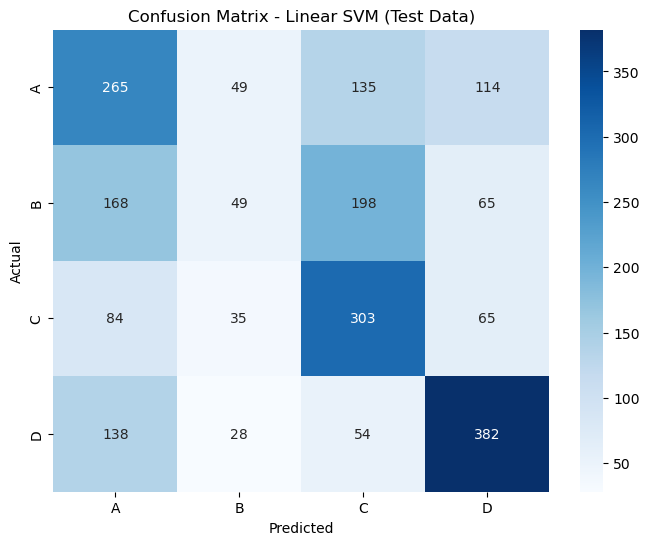

In [11]:
import pandas as pd
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


# Define features and target
X_train = Dataset_Train.drop(columns=['Segmentation'])
y_train = Dataset_Train['Segmentation']
X_test = Dataset_Test.drop(columns=['Segmentation'])
y_test = Dataset_Test['Segmentation']

# Identify column types
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# Process data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Encode target
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Initialize and train Linear SVM
model = LinearSVC(
    C=1.0,  # Regularization parameter
    class_weight='balanced',  # Handle class imbalance
    max_iter=10000,  # Ensure convergence
    random_state=42,
    dual=False  # Recommended for n_samples > n_features
)
model.fit(X_train_processed, y_train_encoded)

# Predictions
y_train_pred = model.predict(X_train_processed)
y_test_pred = model.predict(X_test_processed)

# Convert encoded predictions back to original labels
y_train_pred_labels = le.inverse_transform(y_train_pred)
y_test_pred_labels = le.inverse_transform(y_test_pred)

# Evaluation
print("✅ Train Accuracy:", accuracy_score(y_train, y_train_pred_labels))
print("✅ Test Accuracy:", accuracy_score(y_test, y_test_pred_labels))

print("\n🔹 Classification Report (Train):\n", classification_report(y_train, y_train_pred_labels))
print("\n🔹 Classification Report (Test):\n", classification_report(y_test, y_test_pred_labels))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred_labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion Matrix - Linear SVM (Test Data)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()